<a href="https://colab.research.google.com/github/Ebbeju-Lankapalli/Breast-Cancer-KNN-Classification/blob/main/Breast_Cancer_KNN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Classification using K-Nearest Neighbors (KNN)

## Problem Statement

The objective of this project is to develop a classification model that predicts whether a breast tumor is benign or malignant based on features extracted from a fine needle aspirate of a breast mass.

The model aims to assist medical professionals in making accurate diagnoses and support early detection of breast cancer.

##Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

##Load Dataset

In [2]:
train_url = "https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/Breast_Cancer_Wisconsin_Dataset.csv"
test_url = "https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/Breast_cancer_test_data.csv"

train_data = pd.read_csv(train_url)
test_data = pd.read_csv(test_url)

print(train_data.shape)
print(test_data.shape)

train_data.head()

(558, 11)
(81, 10)


,ID,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1188472,1,1,1,1,1,1,3,1,1,2
1,1223793,6,10,7,7,6,4,8,10,2,4
2,1174057,4,2,1,1,2,2,3,1,1,2
3,706426,5,5,5,2,5,10,4,3,1,4
4,1131411,1,1,1,2,2,1,2,1,1,2


##Data Inspection

In [3]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558 entries, 0 to 557
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   ID                           558 non-null    int64
 1   Clump_Thickness              558 non-null    int64
 2   Cell_Size_Uniformity         558 non-null    int64
 3   Cell_Shape_Uniformity        558 non-null    int64
 4   Marginal_Adhesion            558 non-null    int64
 5   Single_Epithelial_Cell_Size  558 non-null    int64
 6   Bare_Nuclei                  558 non-null    int64
 7   Bland_Chromatin              558 non-null    int64
 8   Normal_Nucleoli              558 non-null    int64
 9   Mitoses                      558 non-null    int64
 10  Class                        558 non-null    int64
dtypes: int64(11)
memory usage: 48.1 KB


In [4]:
train_data.describe()

,ID,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
count,5.580000e+02,558.000000,558.00000,558.000000,558.000000,558.000000,558.000000,558.000000,558.000000,558.000000,558.000000
mean,1.092793e+06,4.460573,3.11828,3.207885,2.883513,3.254480,3.569892,3.440860,2.867384,1.528674,2.713262
std,6.700283e+05,2.792858,3.01647,2.961114,2.900947,2.217064,3.656424,2.415371,3.026569,1.584848,0.958869
min,6.337500e+04,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,1.002145e+06,2.000000,1.00000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.174280e+06,4.000000,1.00000,1.500000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.240536e+06,6.000000,4.75000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [5]:
train_data.isnull().sum()

,0
ID,0
Clump_Thickness,0
Cell_Size_Uniformity,0
Cell_Shape_Uniformity,0
Marginal_Adhesion,0
Single_Epithelial_Cell_Size,0
Bare_Nuclei,0
Bland_Chromatin,0
Normal_Nucleoli,0
Mitoses,0


In [6]:
train_data.duplicated().sum()

np.int64(0)

##Observation
- Dataset contains 558 records.
- No missing values found.
- No duplicate records found.
- All features are numerical.

##Exploratory Data Analysis (EDA)

Class Distribution

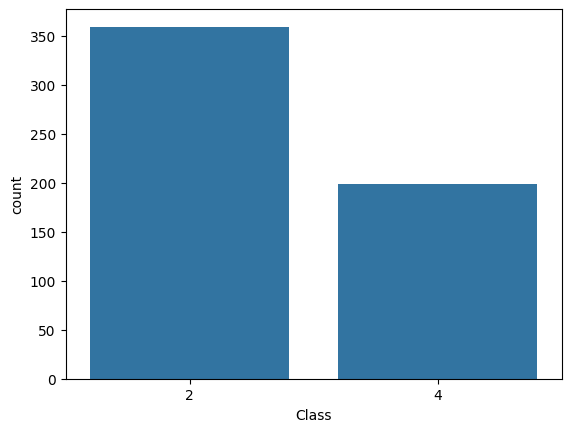

In [7]:
sns.countplot(x='Class', data=train_data)
plt.show()

##Correlation Heatmap

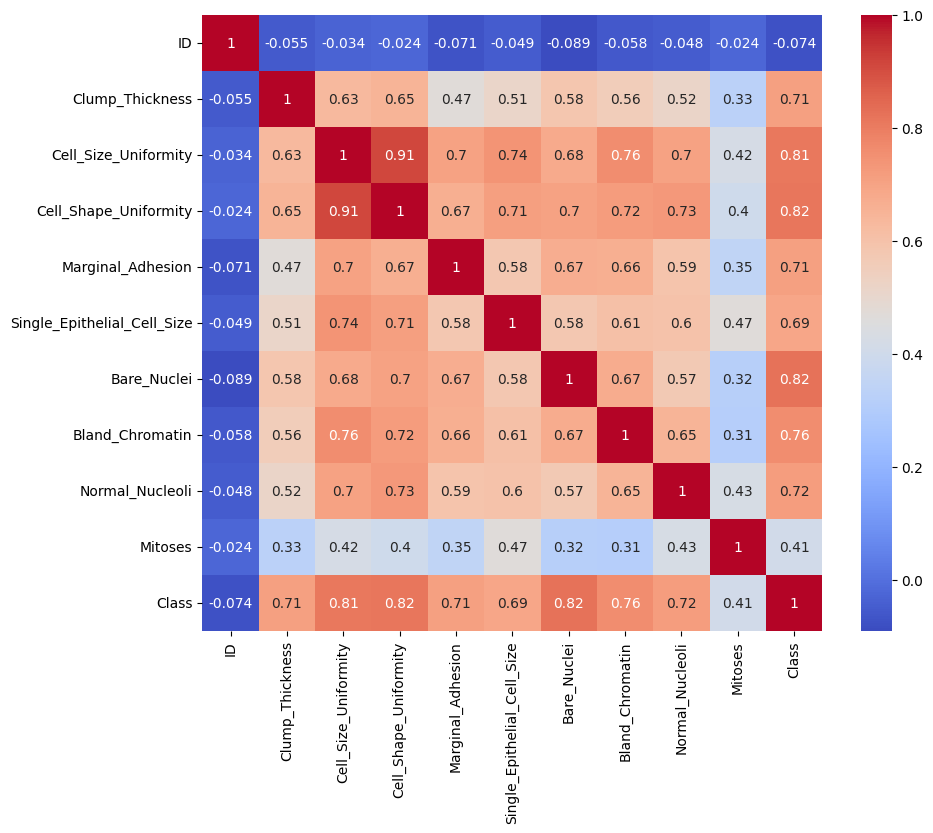

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(
    train_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

##Feature Distribution

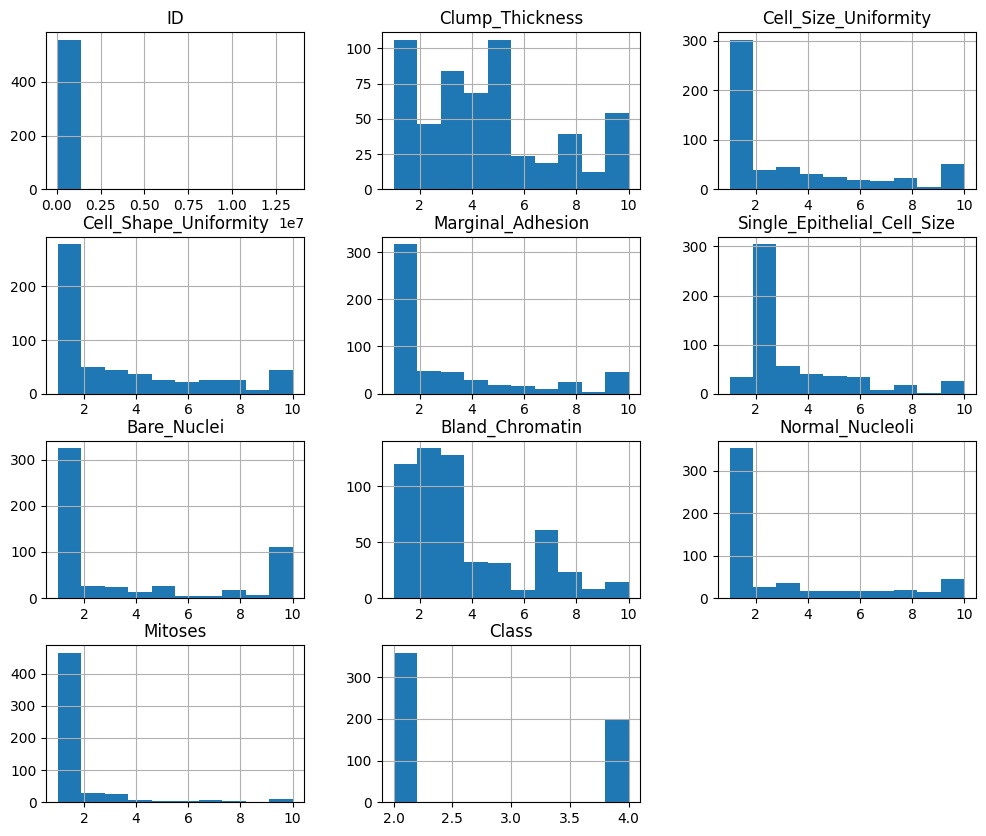

In [9]:
train_data.hist(
    figsize=(12,10)
)

plt.show()

##Pairplot

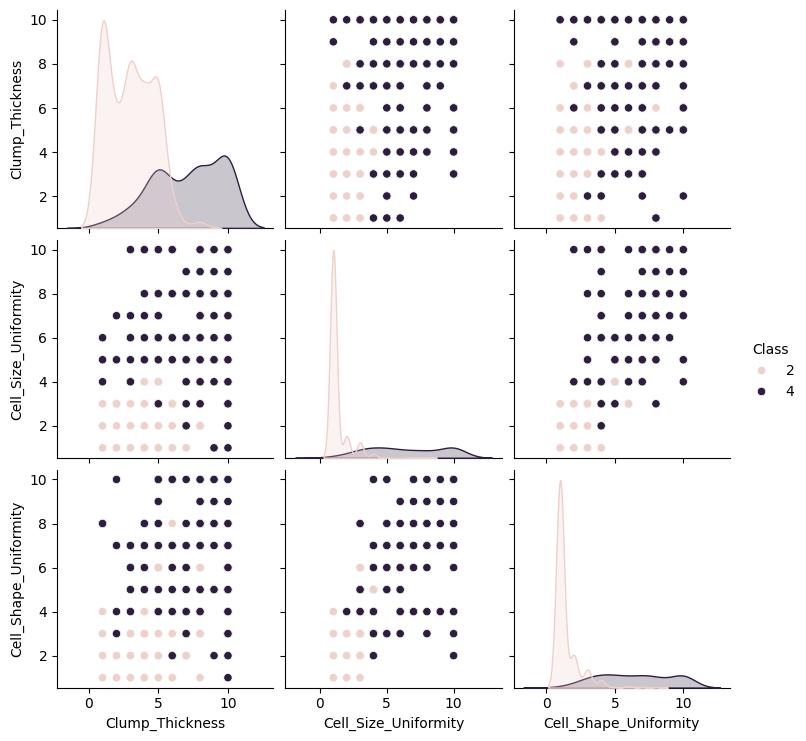

In [10]:
sns.pairplot(
    train_data[['Clump_Thickness',
                'Cell_Size_Uniformity',
                'Cell_Shape_Uniformity',
                'Class']],
    hue='Class'
)

plt.show()

## Feature Engineering

In [11]:
X = train_data.drop(
    ['ID', 'Class'],
    axis=1
)

y = train_data['Class']

##Train-Test Split

In [12]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Finding Optimal K

In [13]:
scores = []

for k in range(1, 41):

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean'
    )

    cv_score = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    ).mean()

    scores.append(cv_score)

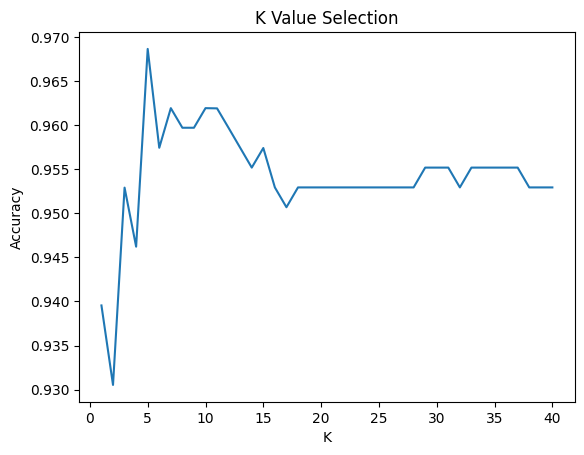

In [14]:
plt.plot(
    range(1,41),
    scores
)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K Value Selection")

plt.show()

In [15]:
best_k = np.argmax(scores) + 1

print("Best K:", best_k)

Best K: 5


##Train Final Model

In [16]:
final_model = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)

final_model.fit(
    X_train,
    y_train
)

KNeighborsClassifier(metric='euclidean', n_neighbors=32)

##Evaluate Model

In [17]:
predictions = final_model.predict(
    X_valid
)

accuracy = accuracy_score(
    y_valid,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.9910714285714286


In [18]:
print(
    classification_report(
        y_valid,
        predictions
    )
)

              precision    recall  f1-score   support

           2       0.99      1.00      0.99        72
           4       1.00      0.97      0.99        40

    accuracy                           0.99       112
   macro avg       0.99      0.99      0.99       112
weighted avg       0.99      0.99      0.99       112



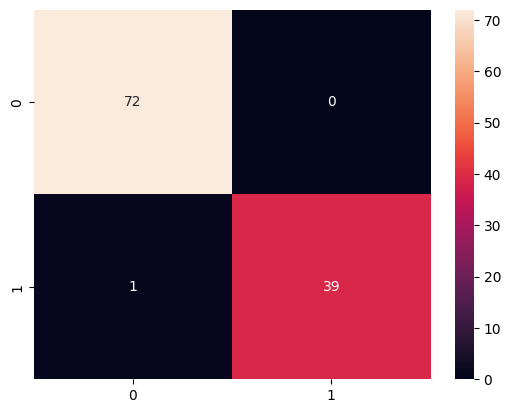

In [19]:
sns.heatmap(
    confusion_matrix(y_valid, predictions),
    annot=True,
    fmt='d'
)

plt.show()

##Predict Test Data

In [21]:
X_test = test_data.drop(
    'ID',
    axis=1
)
test_predictions = final_model.predict(
    X_test
)

In [22]:
submission_df = pd.DataFrame({
    'ID': test_data['ID'],
    'Class': test_predictions
})

submission_df.head()

,ID,Class
0,76389,4
1,142932,4
2,183913,2
3,255644,4
4,263538,4


## Conclusion

- Built a Breast Cancer Classification model using KNN.
- Performed data inspection and exploratory data analysis.
- Verified that the dataset contained no missing values.
- Evaluated multiple K values and selected the optimal value.
- Trained the final KNN classifier.
- Generated predictions for unseen test data.
- The model successfully classifies tumors as Benign (2) or Malignant (4).